In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math


In [2]:
def plot_all_clusters(df_data, df_centroids, macrozona, col_medida, titulo_principal):
    clusters = sorted(df_centroids[df_centroids["macrozona"] == macrozona]["id_cluster"].unique())
    n_clusters = len(clusters)
    
    if n_clusters == 0:
        print(f"No se encontraron clusteres para {macrozona}.")
        return

    # 1. Define dinámicamente la cuadrícula de subgráficos (filas y columnas) según la cantidad de clústeres
    if n_clusters <= 3:
        n_cols, n_rows = n_clusters, 1
    elif n_clusters == 4:
        n_cols, n_rows = 2, 2  
    elif n_clusters in [5, 6]:
        n_cols, n_rows = 3, 2
    elif n_clusters in [7, 8]:
        n_cols, n_rows = 4, 2
    else:
        n_cols = 3 if n_clusters <= 9 else 4
        n_rows = math.ceil(n_clusters / n_cols)

    fig_width = max(12, 5 * n_cols)
    fig_height = 4.5 * n_rows
    
    # Configura la figura compartiendo la escala de los ejes X e Y para permitir una comparación visual justa
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), sharex=True, sharey=True)
    fig.suptitle(f"{titulo_principal}\nMacrozona: {macrozona}", fontsize=16, fontweight='bold', y=1.05 if n_rows == 1 else 1.02)
    
    axes = np.array(axes).flatten() if n_clusters > 1 else [axes]
    horas = np.arange(1, 25)

    for i, cluster in enumerate(clusters):
        ax = axes[i]
        
        # Aísla los datos de los clientes que pertenecen a este clúster y extrae el identificador de su centroide
        miembros = df_data[(df_data["macrozona"] == macrozona) & (df_data["id_cluster"] == cluster)]
        centro = df_centroids[(df_centroids["macrozona"] == macrozona) & (df_centroids["id_cluster"] == cluster)]
        
        # El medoid es un cliente real que actúa como representante central del clúster
        clave_medoid = centro["clave_medoid"].iloc[0]
        n_miembros = miembros["clave_unica"].nunique()

        curvas_miembros = []
        horas = np.arange(1, 25)

        # Grafica el perfil de consumo horario de cada miembro en gris claro para visualizar la dispersión general
        for cliente in miembros["clave_unica"].unique():
            curva = miembros[miembros["clave_unica"] == cliente].sort_values("Hora")[col_medida].to_numpy()
            curvas_miembros.append(curva)
            ax.plot(horas, curva, color='gray', alpha=0.25, linewidth=0.8, zorder=1)
        
        curvas_miembros = np.array(curvas_miembros)

        # Sombrea la zona donde se concentra el 80% central de los perfiles, filtrando valores atípicos extremos
        if n_miembros > 2:
            p10 = np.percentile(curvas_miembros, 10, axis=0)
            p90 = np.percentile(curvas_miembros, 90, axis=0)
            ax.fill_between(horas, p10, p90, color='blue', alpha=0.08, zorder=2, label='Nucleo central 80%')

        # Resalta en negro y mayor grosor la curva exacta del representante (medoid) del clúster
        curva_medoid = miembros[miembros["clave_unica"] == clave_medoid].sort_values("Hora")[col_medida].to_numpy()
        ax.plot(horas, curva_medoid, color='black', linewidth=2.5, zorder=5, label='Representante')

        ax.set_title(f"Cluster {cluster} ({n_miembros} claves)")
        ax.set_xticks([1, 6, 12, 18, 24])
        ax.grid(True, alpha=0.3)
        if i % n_cols == 0:
            ax.set_ylabel("Participacion Diaria")
        
    # Oculta los ejes de los subgráficos sobrantes si la cuadrícula generada es mayor al total de clústeres
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [3]:
carpeta_datos = Path(r"D:\ProyectoAnalisisElectrico\PotencialesClientes")

print("Cargando versión Porcentual...")
df_centros_pct = pd.read_parquet(carpeta_datos / "2505_2604_centroids_porcentual_actives.parquet")
df_clusterizado_pct = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual_actives.parquet")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


Cargando versión Porcentual...


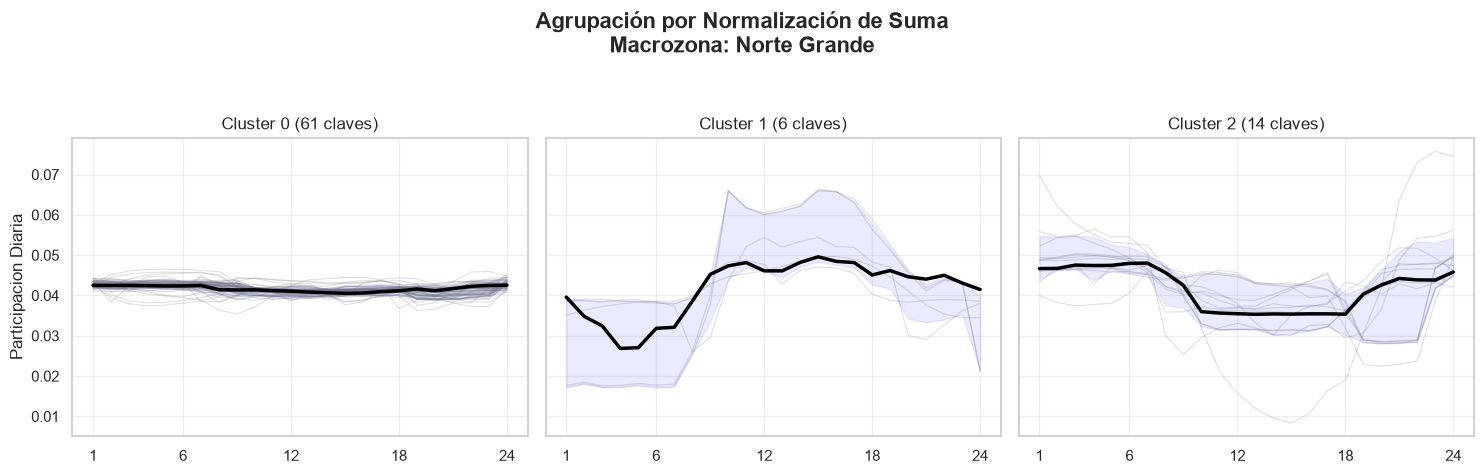

In [4]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Norte Grande", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

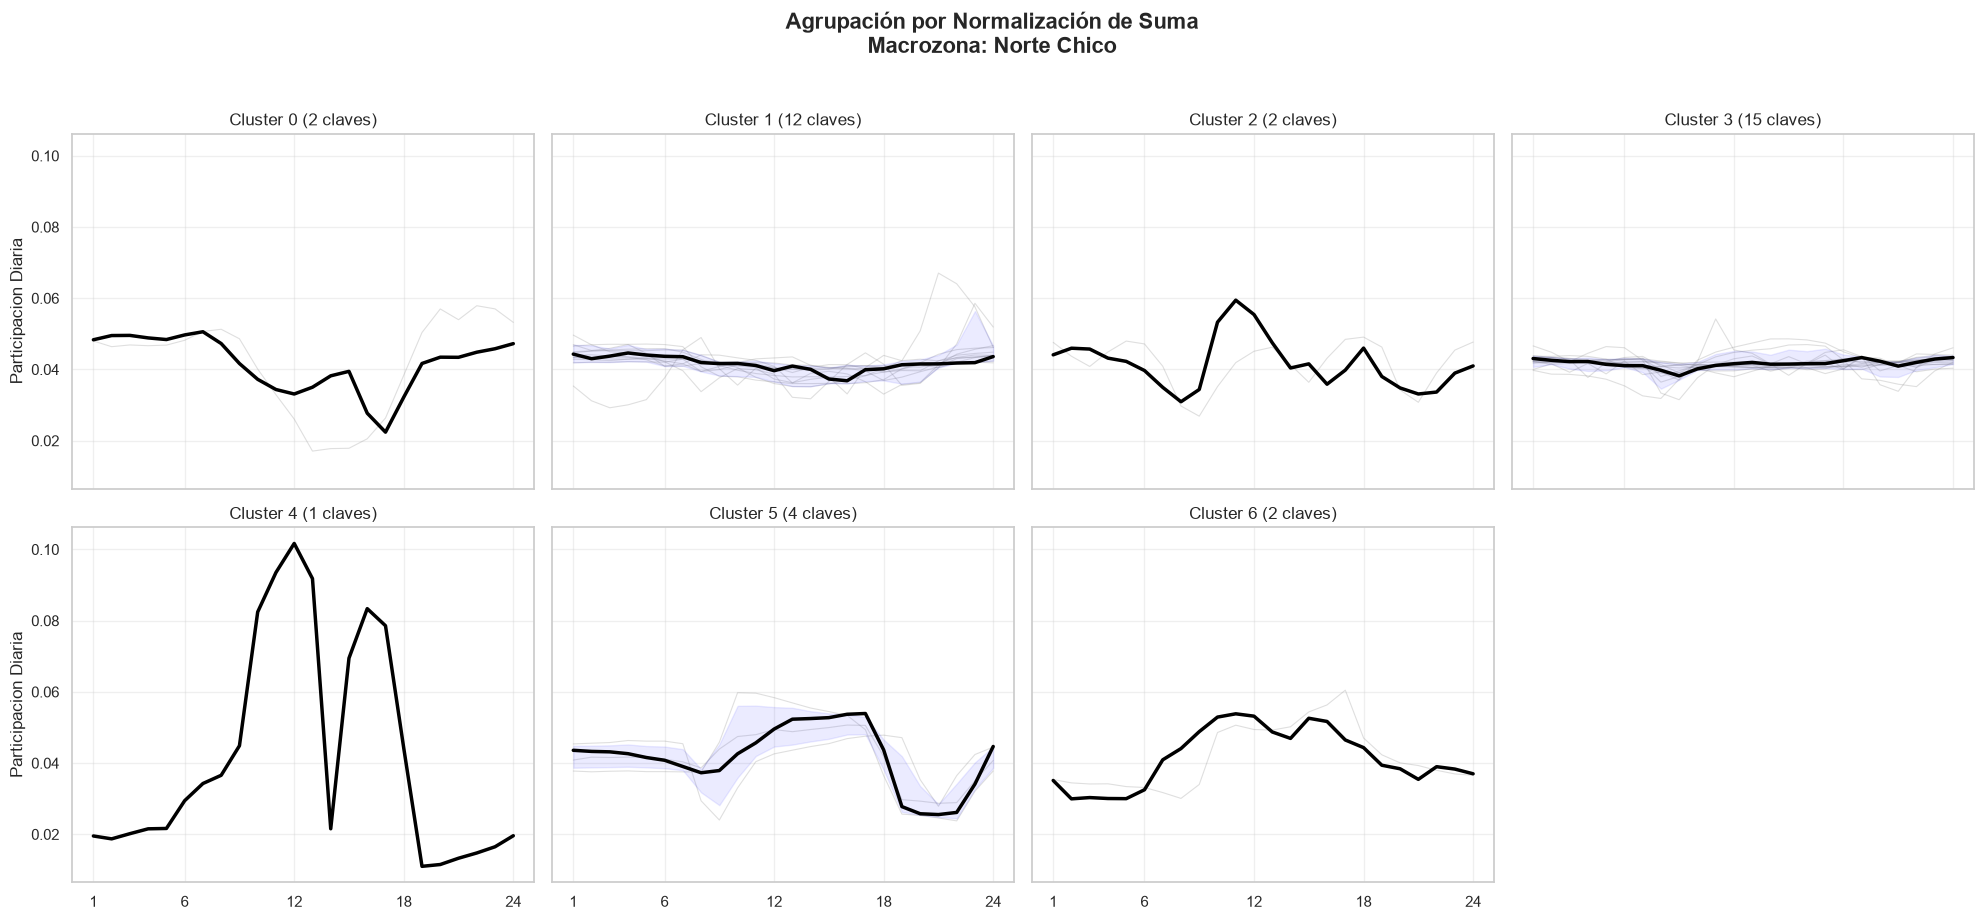

In [5]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Norte Chico", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

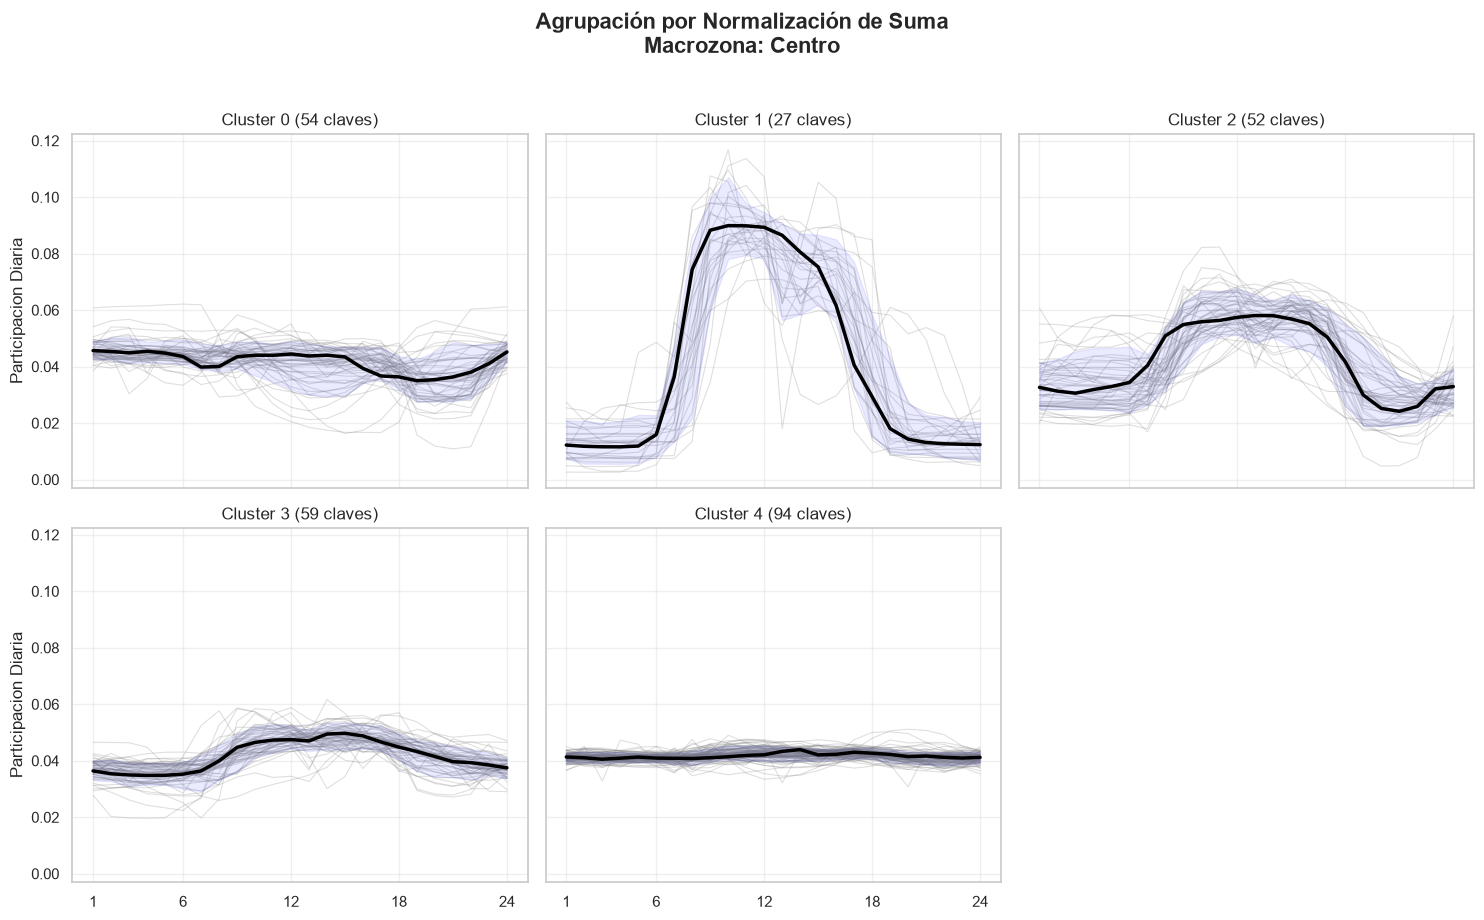

In [6]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Centro", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

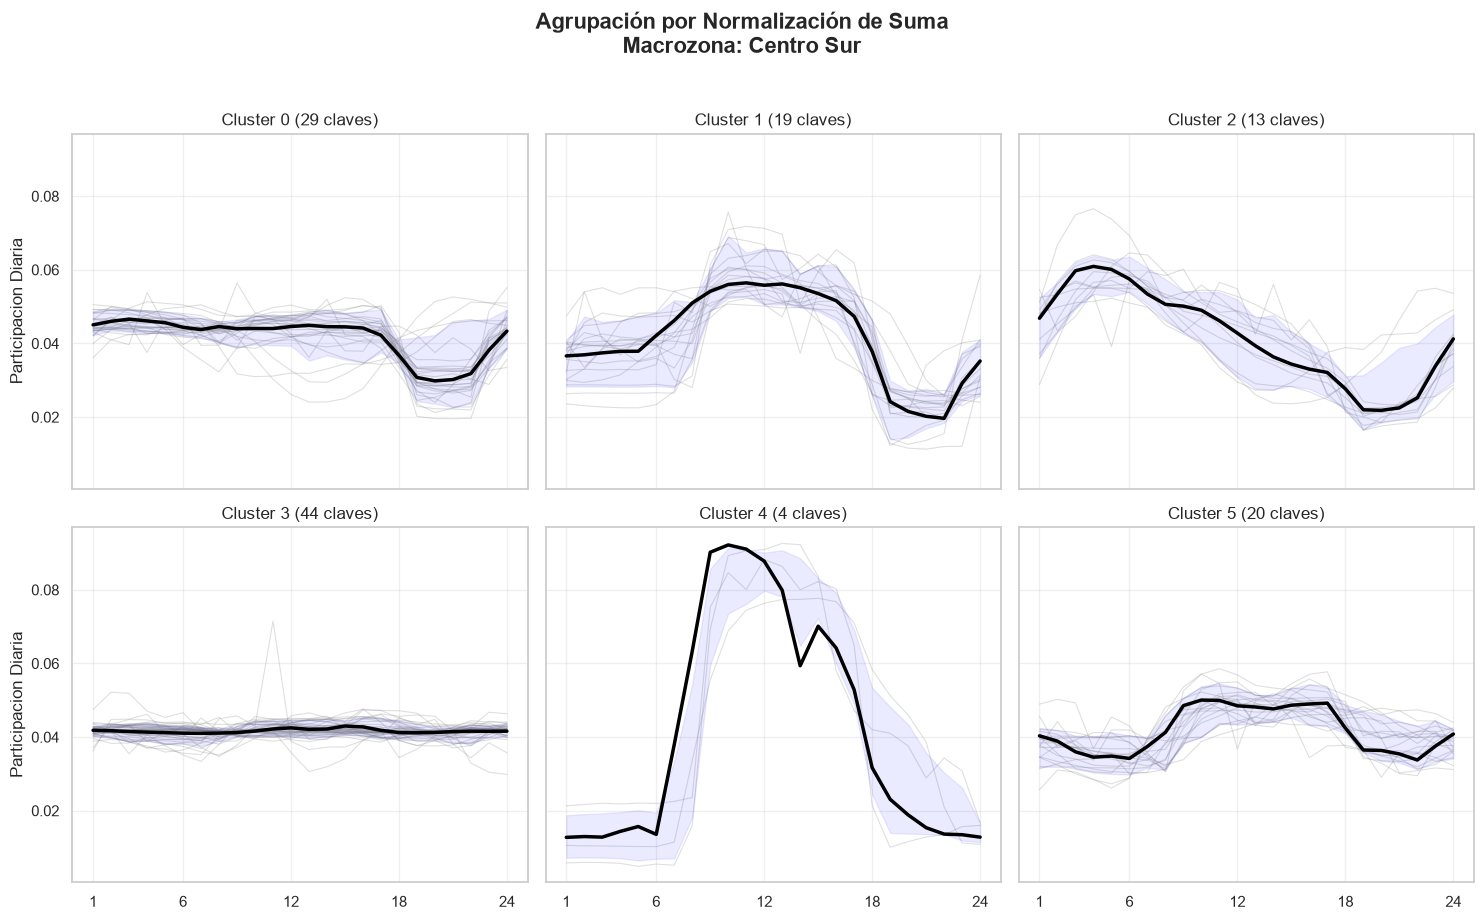

In [7]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Centro Sur", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)

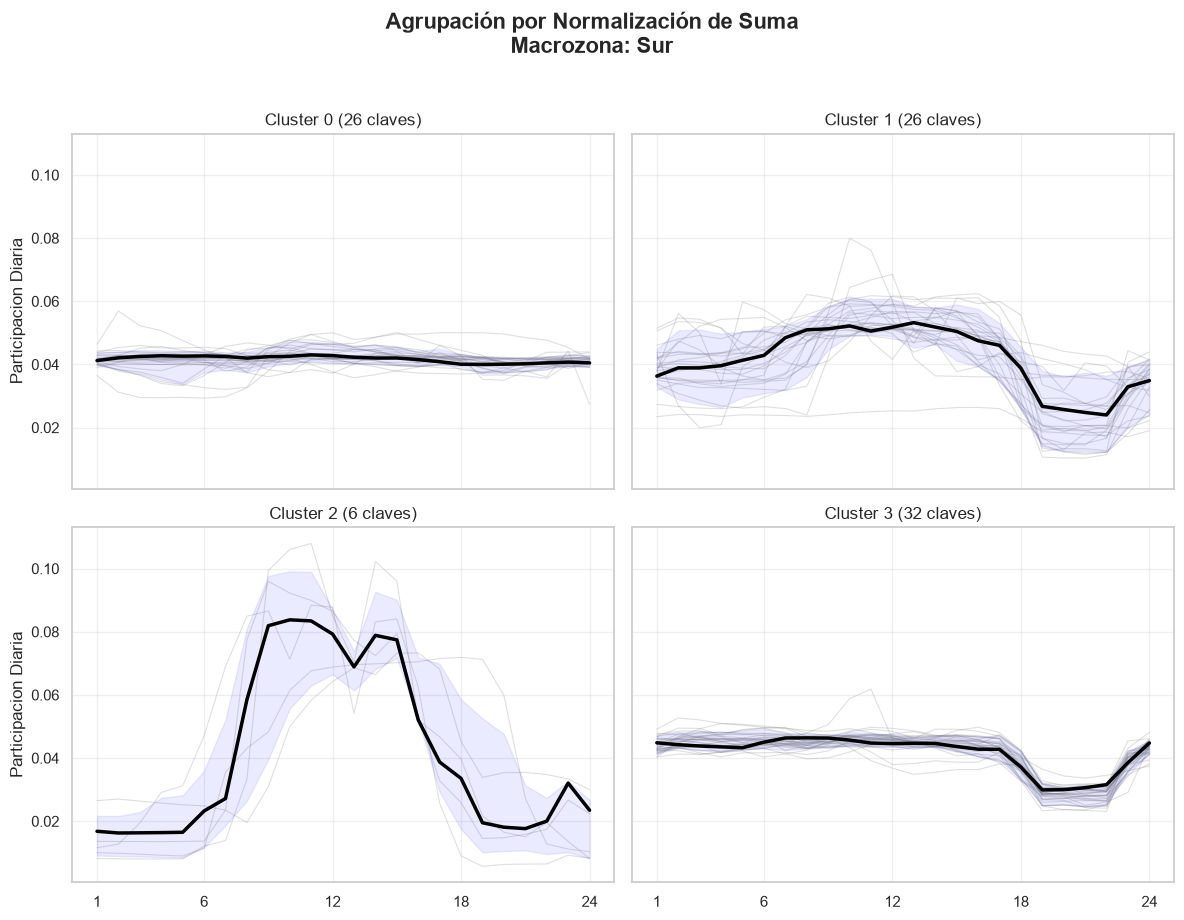

In [8]:
plot_all_clusters(
    df_data=df_clusterizado_pct, 
    df_centroids=df_centros_pct, 
    macrozona="Sur", 
    col_medida="medida_porcentual", 
    titulo_principal="Agrupación por Normalización de Suma"
)